#### **Imports**

In [ ]:
import sys
sys.path.append("../")
sys.path.append("../../simtest/")

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import matplotlib.patheffects as path_effects
import matplotlib as mpl

import numpy as np
import pandas as pd
import joblib
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

from models.cvae_lightning import LitVAE
from models.cbegan_lightning import SpectralCBEGAN
from utils.utils import encode_labels
from matplotlib.patches import Ellipse

from DataClasses.DataClasses import PytorchSpectraDataset
from attokit.variability.variability import calculate_ioi
import umap

#### **Pretrained Model**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Modelle und Scaler laden ---
checkpoint_cvae = torch.load("../pretrained_models/weights_cvae.ckpt", map_location=device, weights_only=False)
hparams_cvae = checkpoint_cvae['hyper_parameters']
cvae_model = LitVAE(**hparams_cvae).to(device)
cvae_model.load_state_dict(checkpoint_cvae['state_dict'])
cvae_model.eval()
print("CVAE loaded.")

## cbegan
cbegan_model = SpectralCBEGAN.load_from_checkpoint("../pretrained_models/weights_cbegan.ckpt", map_location=device)
cbegan_model.eval()
print("CBEGAN loaded.")

Using device: cpu
Using cyclical annealing.
CVAE loaded.
CBEGAN loaded.


#### **Data Loading**

In [3]:
dataset = PytorchSpectraDataset("../data/h4h_raw_2024-09-16_with_subject_ids.parquet")
meta_df = pd.read_csv('../data/h4h_basic_data.csv')
df = dataset.df_train_scaled

df = df.merge(
    meta_df[['sample_id', 'redcap_event_name']],
    on='sample_id',
    how='left'
)

df = df.rename(columns = {"redcap_event_name": "visit"})
df['visit'] = df['visit'].str.extract(r'(\d+)').astype(int)

feature_cols = df.columns[:519]
minmax_scaler = dataset.min_max_scaler

print("Loaded data")

Loaded data


# **1.) Patient Visit Trajectories**

In [130]:
def generate_full_trajectory(subject_id, df, model):
    """
    Generates a real and simulated spectral trajectory for a given subject
    using either a CVAE or CBEGAN model.
    """
    device = model.device
    subject_visits = df[df['subject_id'] == subject_id].sort_values(by='visit')
    print(f"--- Creating trajectory for Subject {subject_id} over {len(subject_visits)} visits ---")

    real_spectra, simulated_spectra = [], []
    feature_cols = subject_visits.columns[:519]

    # Check if the model is CBEGAN or CVAE
    is_cbegan = hasattr(model, 'generator')
    is_cvae = hasattr(model, 'vae')

    # Determine embedding dimension based on model type
    if is_cbegan:
        embedding_dim = model.pos_encoding_embedding_size
    elif is_cvae:
        embedding_dim = model.vae.pos_encoding_embedding_dim
    else:
        raise ValueError("Model type not recognized. Must be CBEGAN or CVAE.")


    for i in range(len(subject_visits)):
        current_visit = subject_visits.iloc[i]
        real_spectra.append(current_visit[feature_cols].values)

        if i > 0:
            previous_visit = subject_visits.iloc[i-1]
            previous_spectrum = torch.tensor(previous_visit[feature_cols].values.astype(np.float32)).unsqueeze(0).to(device)

            # --- Condition Dictionaries ---
            # Previous visit conditions
            previous_condition_dict = previous_visit[['age', 'sex', 'bmi']].to_dict()
            for key, value in previous_condition_dict.items():
                previous_condition_dict[key] = torch.tensor([value], dtype=torch.float32).to(device)

            # Current visit conditions (for decoding/generation)
            current_condition_dict = current_visit[['age', 'sex', 'bmi']].to_dict()
            for key, value in current_condition_dict.items():
                current_condition_dict[key] = torch.tensor([value], dtype=torch.float32).to(device)


            with torch.no_grad():
                if is_cvae:
                    # CVAE: Encode previous, decode with current conditions
                    _, mu, logvar = model.vae.encode(previous_spectrum, previous_condition_dict)
                    latent_vector = model.vae.sample(mu, logvar)
                    simulated_spectrum = model.vae.decode(latent_vector, current_condition_dict)

                elif is_cbegan:
                    # CBEGAN: Use discriminator's encoder, then generator with current conditions
                    latent_vector = model.discriminator.encoder(previous_spectrum)
                    encoded_conditions = encode_labels(current_condition_dict, embedding_dim, device=device)
                    simulated_spectrum = model.generator(latent_vector, encoded_conditions)

            simulated_spectra.append(simulated_spectrum.cpu().numpy())

    return {
        "subject_id": subject_id,
        "real_spectra": np.array(real_spectra),
        "simulated_spectra": np.array(simulated_spectra),
    }

In [5]:
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1)

# Fitte das Modell auf allen Daten und transformiere sie für den Hintergrund-Plot
all_points_umap = reducer.fit_transform(df[feature_cols])
print("UMAP fitted.")
print("-" * 60)

c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP fitted.
------------------------------------------------------------


--- Creating trajectory for Subject H4H_05_0108 over 6 visits ---
Erstelle Trajektorie für Proband H4H_05_0108...


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure

--- Creating trajectory for Subject H4H_16_0343 over 6 visits ---
Erstelle Trajektorie für Proband H4H_16_0343...
--- Creating trajectory for Subject H4H_05_0106 over 6 visits ---
Erstelle Trajektorie für Proband H4H_05_0106...


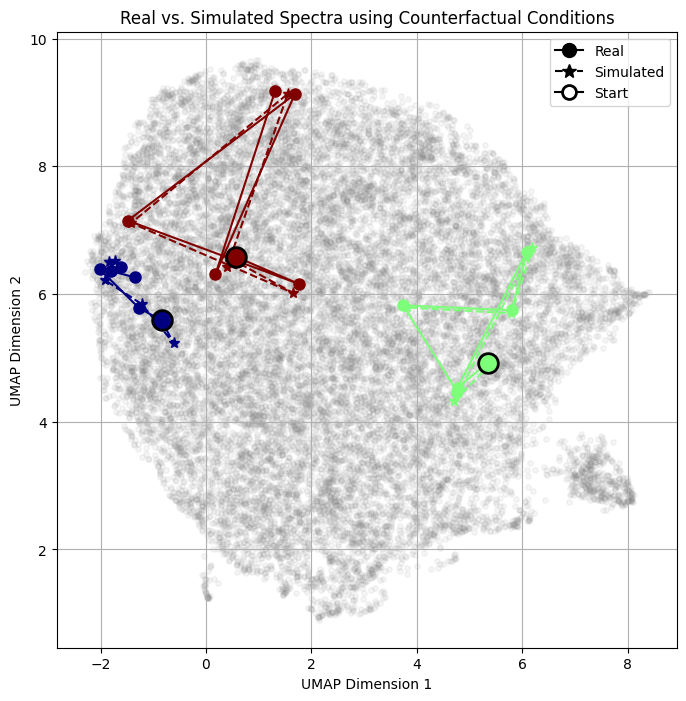

In [6]:
N_PATIENTS_TO_ANALYZE = 3
RANDOM_SEED = 99
model = cvae_model
np.random.seed(RANDOM_SEED)

visit_counts = df['subject_id'].value_counts()
suitable_subjects = visit_counts[visit_counts >= 6].index
subjects_to_analyze = np.random.choice(suitable_subjects, N_PATIENTS_TO_ANALYZE, replace=False)


# --- Erstelle die Abbildung VOR der Schleife ---
#plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.jet(np.linspace(0, 1, N_PATIENTS_TO_ANALYZE)) # Farbpalette für N Probanden
ax.scatter(all_points_umap[:, 0], all_points_umap[:, 1], c='gray', alpha=0.08, s=15, label='Gesamtpopulation')


for i, subject_id in enumerate(subjects_to_analyze):
    
    results = generate_full_trajectory(
        subject_id=subject_id,
        df=df,
        model=model
    )

    if results:
        print(f"Erstelle Trajektorie für Proband {subject_id}...")

        real_umap = reducer.transform(results['real_spectra'])
        simulated_umap = reducer.transform(results["simulated_spectra"].squeeze(1))      
        
        color = colors[i]

        # --- Real trajectory ---
        ax.plot(real_umap[:, 0], real_umap[:, 1], '-o', color=color, 
                label=f'Echt (Subj {i+1})', markersize=8, zorder=5)

        # highlight start point (real[0]) with black edge
        ax.scatter(real_umap[0, 0], real_umap[0, 1], 
                   s=200, facecolor=color, edgecolor='black', 
                   linewidth=2, marker='o', zorder=10, 
                   label=f'Start (Subj {i+1})')

        # --- Simulated trajectory (shifted by one) ---
        ax.plot(np.vstack([real_umap[0], simulated_umap])[:, 0], 
                np.vstack([real_umap[0], simulated_umap])[:, 1], 
                '--*', color=color, 
                label=f'Simuliert (Subj {i+1})', markersize=8, zorder=4)

# --- Konfiguriere und zeige die finale Abbildung ---
ax.set_title(f'Real vs. Simulated Spectra using Counterfactual Conditions')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
# Die Legende kann sehr lang werden, daher platzieren wir sie außerhalb
legend_elements = [
    Line2D([0], [0], color='black', marker='o', linestyle='-', label='Real', markersize=10),
    Line2D([0], [0], color='black', marker='*', linestyle='--', label='Simulated', markersize=10),
    Line2D([0], [0], marker='o', color='black', markersize=10,
           markerfacecolor='white', markeredgewidth=2, label='Start')
]

ax.legend(handles=legend_elements)
ax.grid(True)
plt.show()
ax.grid(True)
plt.show()

# **2.) Real Aging**

In [7]:
def prepare_age_cohorts(df):
    """Define cohorts based on the 5th and 95th age percentiles."""
    age_quartiles_scaled = df['age'].quantile([0.05, 0.95])
    youngest_q_threshold = age_quartiles_scaled.loc[0.05]
    oldest_q_threshold = age_quartiles_scaled.loc[0.95]

    youngest = df[df['age'] <= youngest_q_threshold]
    oldest = df[df['age'] >= oldest_q_threshold]

    return youngest, oldest

In [154]:
def select_age_correlated_features(df, feature_cols, n_top_features=20):
    """Return the top n features most correlated with age."""
    correlations = df[feature_cols].corrwith(df['age'])
    abs_corr = correlations.abs().sort_values(ascending=False)
    selected_features = abs_corr.head(n_top_features).index.tolist()
    return selected_features


# from sklearn.cross_decomposition import PLSCanonical, PLSRegression, CCA
# def vip_score(model):
#     """
#     Calculate the VIP score for a fitted PLS model.
#     """
#     t = model.x_scores_
#     w = model.x_weights_
#     q2 = model.y_loadings_
#     h = w.shape[1]
#     p, _ = w.shape
#     vip = np.zeros(p)

#     # Explained variance for each component
#     explained_variance_y = np.sum(q2**2, axis=0) * np.var(model.y_scores_)

#     for i in range(p):
#         v = np.sqrt(p * np.sum(explained_variance_y * (w[i,:]**2)) / np.sum(explained_variance_y))
#         vip[i] = v

#     return vip

# def select_age_correlated_features(df, feature_cols, threshold=1):
#     """Return features with vip>1 for age."""
#     pls = PLSRegression()
#     pls.fit(df[feature_cols].values, df['age'].values)
#     vip = vip_score(pls)
#     selected_features = feature_cols[vip>threshold]
#     return selected_features.values


# import pandas as pd
# from scipy.stats import pearsonr
# from statsmodels.stats.multitest import multipletests
# def select_age_correlated_features(df: pd.DataFrame, feature_cols, threshold: float = 0.05):
#     """
#     Selects wavenumbers significantly associated with age (y) using Pearson correlation + FDR correction.
    
#     Parameters
#     ----------
#     df : pd.DataFrame
#         FTIR spectra (rows = individuals, cols = wavenumbers).
#     y : array-like
#         Age values corresponding to rows of df.
#     threshold : float, default=0.05
#         FDR significance threshold.
        
#     Returns
#     -------
#     significant_df : pd.DataFrame
#         Subset of df with only significant wavenumber columns.
#     results : pd.DataFrame
#         DataFrame with correlation, raw p-values, adjusted p-values, and significance flag.
#     """
    
#     correlations, pvals = [], []
    
#     for col in feature_cols:
#         r, p = pearsonr(df[col], df['age'].values)
#         correlations.append(r)
#         pvals.append(p)
    
#     # Multiple testing correction
#     rejected, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')
    
#     results = pd.DataFrame({
#         "wavenumber": feature_cols,
#         "correlation": correlations,
#         "pval_raw": pvals,
#         "pval_fdr": pvals_corrected,
#         "significant": rejected
#     })
    
#     # Filter significant wavenumbers
#     sig_cols = results.loc[results["pval_fdr"] < threshold, "wavenumber"]
    
#     return sig_cols.values, results


def select_highest_ioi_features(df, feature_cols, n_top_features=20):
    ioi = calculate_ioi(df, feature_cols)
    top_n_columns = ioi.iloc[0].nsmallest(n_top_features).index.tolist()
    return top_n_columns

In [207]:
def fit_umap(df, feature_cols, n_neighbors=15, min_dist=0.1, random_state=42):
    """Fit a UMAP reducer on selected features of df."""
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state)
    embedding = reducer.fit_transform(df[feature_cols])
    return reducer, embedding

## 2.1 Highlight age and ioi regions

In [159]:
def get_relevant_features(df, scaler_path="../pretrained_models/scalers/std_scaler.pkl", n_age_features=30, n_ioi_features=30):

    standard_scaler = joblib.load(scaler_path)

    age_features = select_age_correlated_features(df, df.columns[:519], n_age_features)
    ioi_features = select_highest_ioi_features(df, df.columns[:519], n_ioi_features)

    correlations = df[df.columns[:519]].corrwith(df['age'])
    abs_corr = correlations.abs()
    ioi = calculate_ioi(df, df.columns[:519])

    top_n_ioi = ioi.iloc[0].nsmallest(n_ioi_features).values
    ioi = ioi.values[0]
    top_n_abs_corr = abs_corr.nlargest(30).values

    return {
    "scaler": standard_scaler,
    "age_features": age_features,
    "ioi_features": ioi_features,
    "abs_corr": abs_corr,
    "ioi": ioi,
    "top_n_ioi": top_n_ioi,
    "top_n_abs_corr": top_n_abs_corr
    }

In [175]:
def plot_feature_sets(df, feature_data, save_path):
    standard_scaler = feature_data["scaler"]
    age_features = feature_data["age_features"]
    ioi_features = feature_data["ioi_features"]
    abs_corr = feature_data["abs_corr"]
    ioi = feature_data["ioi"]
    top_n_ioi = feature_data["top_n_ioi"]
    top_n_abs_corr = feature_data["top_n_abs_corr"]


    # --- Precompute values ---
    x_axis = df.columns[:519].values.astype(float)
    mean_spectrum = np.mean(standard_scaler.inverse_transform(df.iloc[:, :519]), axis=0)


    age_set, ioi_set = set(age_features), set(ioi_features)


    # --- Setup figure ---
    fig, axs = plt.subplots(3, 2, figsize=(8, 9), gridspec_kw={'height_ratios':[1,1.5,1]}, width_ratios=[75, 20])
    (ax1_left, ax1_right), (ax2_left, ax2_right), (ax3_left, ax3_right) = axs


    # ---------------- TOP: IOI ----------------
    ax1_left.plot(x_axis, ioi, color="black", lw=1.2)
    ax1_right.plot(x_axis, ioi, color="black", lw=1.2)


    for i, col in enumerate(df.columns[:519]):
        if col in ioi_set:
            ax1_left.axvspan(x_axis[i], x_axis[i], color="red", alpha=0.3)
            ax1_right.axvspan(x_axis[i], x_axis[i], color="red", alpha=0.3)


    ax1_left.set_ylabel("IOI", fontsize=12)


    # ---------------- MIDDLE: Spectrum ----------------
    ax2_left.plot(x_axis, mean_spectrum, color="black", lw=1.2)
    ax2_right.plot(x_axis, mean_spectrum, color="black", lw=1.2)


    for i, col in enumerate(df.columns[:519]):
        if col in age_set and col in ioi_set:
            ax2_left.axvspan(x_axis[i], x_axis[i], color="purple", alpha=0.3)
            ax2_right.axvspan(x_axis[i], x_axis[i], color="purple", alpha=0.3)
        elif col in age_set:
            ax2_left.axvspan(x_axis[i], x_axis[i], color="blue", alpha=0.3)
            ax2_right.axvspan(x_axis[i], x_axis[i], color="blue", alpha=0.3)
        elif col in ioi_set:
            ax2_left.axvspan(x_axis[i], x_axis[i], color="red", alpha=0.3)
            ax2_right.axvspan(x_axis[i], x_axis[i], color="red", alpha=0.3)


    ax2_left.axhline(y=0, color="gray", linestyle="--")
    ax2_right.axhline(y=0, color="gray", linestyle="--")
    ax2_left.set_ylabel("Absorbance [a.u.]", fontsize=12)


    # ---------------- BOTTOM: Age Correlation ----------------
    ax3_left.plot(x_axis, abs_corr, color="black", lw=1.2)
    ax3_right.plot(x_axis, abs_corr, color="black", lw=1.2)


    for i, col in enumerate(df.columns[:519]):
        if col in age_set:
            ax3_left.axvspan(x_axis[i], x_axis[i], color="blue", alpha=0.3)
            ax3_right.axvspan(x_axis[i], x_axis[i], color="blue", alpha=0.3)


    ax3_left.set_ylabel("Abs Corr(Age)", fontsize=12)
    ax3_left.set_xlabel("Wavenumber [1/cm]", fontsize=12)


    # --- Broken axis config ---
    def setup_broken_axis(ax_left, ax_right, xlim_left=(1000,1750), xlim_right=(2800,3000)):
        ax_left.set_xlim(*xlim_left)
        ax_right.set_xlim(*xlim_right)


        # Add grid
        #ax_left.grid(True, linestyle="--", alpha=0.6)
        #ax_right.grid(True, linestyle="--", alpha=0.6)


        d = .015
        kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
        ax_left.plot((1-d*(20/75),1+d*(20/75)),(-d,+d), linewidth=1, **kwargs)
        ax_left.plot((1-d*(20/75),1+d*(20/75)),(1-d,1+d), linewidth=1, **kwargs)
        kwargs.update(transform=ax_right.transAxes)
        ax_right.plot((-d,d),(-d,+d), linewidth=1, **kwargs)
        ax_right.plot((-d,d),(1-d,1+d), linewidth=1, **kwargs)


        ax_left.spines['right'].set_visible(False)
        ax_right.spines['left'].set_visible(False)
        ax_left.yaxis.tick_left()
        ax_right.yaxis.set_major_locator(ticker.NullLocator())


    # Apply to all three rows
    setup_broken_axis(ax1_left, ax1_right)
    setup_broken_axis(ax2_left, ax2_right)
    setup_broken_axis(ax3_left, ax3_right)


    # --- Legend ---
    top_n_ioi = feature_data['top_n_ioi']
    top_n_abs_corr = feature_data['top_n_abs_corr']

    legend_elements = [
    Line2D([0], [0], color="black", lw=1.5, label="Mean spectrum"),
    Patch(facecolor="blue", alpha=0.3, label=f"Top {len(top_n_ioi)} Age features"),
    Patch(facecolor="red", alpha=0.3, label=f"Top {len(top_n_abs_corr)} IOI features")
    ]
    ax2_right.legend(handles=legend_elements, fontsize=10, loc="upper right")


    fig.suptitle("Region subselection for UMAP", fontsize=16, y=0.92)
    plt.subplots_adjust(hspace=0.25, wspace=0.15)
    plt.savefig(save_path)
    plt.show()

c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


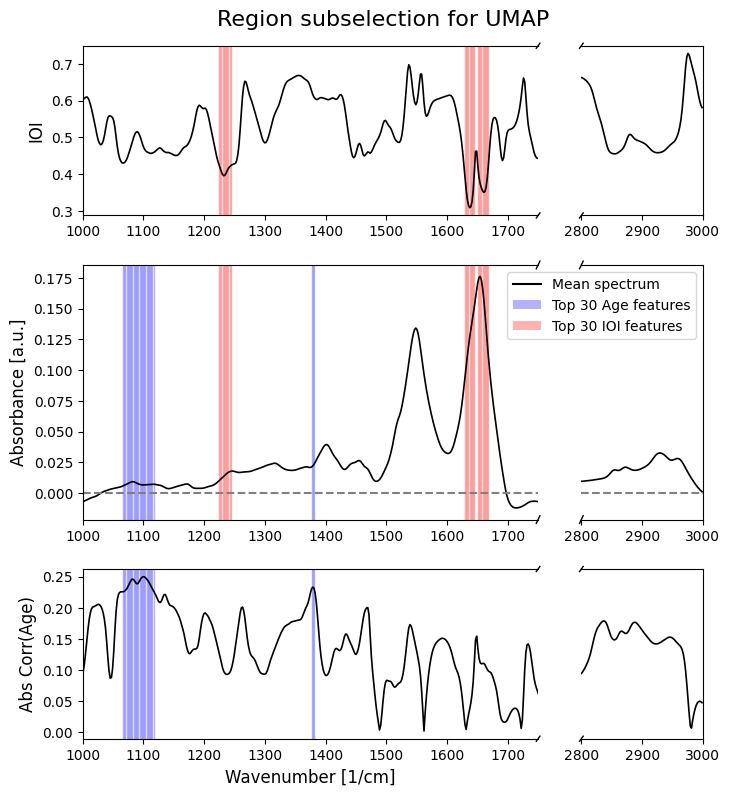

In [176]:
data_for_plotting = get_relevant_features(df)

plot_feature_sets(
    df = df, 
    feature_data = data_for_plotting, 
    save_path = 'aging_and_ioi_regions.pdf'
)

## 2.2 Aging Trajectories

In [212]:
def analyze_aging_simulation(
    df,
    feature_cols,
    model,
    scaler,
    n_subjects=10,
    n_top_features=30,
    n_samples_per_step=1,
    simulation_steps=4,
    age_step=8,
    umap_params=None,
    random_seed=42,
    feature_selection_method='age_corr'
):
    """
    Performs the aging simulation and UMAP analysis.
    """
    # --- Set global seeds for reproducibility ---
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass  # not available in older PyTorch versions
    
    umap_params = umap_params or {"n_neighbors": 15, "min_dist": 0.1, "random_state": random_seed}

    print(f"Selecting features using '{feature_selection_method}' method...")
    if feature_selection_method == 'age_corr':
        selected_features = select_age_correlated_features(df, feature_cols, n_top_features)
    elif feature_selection_method == 'ioi':
        selected_features = select_highest_ioi_features(df, feature_cols, n_top_features)
    else:
        raise ValueError(f"Unknown feature_selection_method: '{feature_selection_method}'")

    print("Fitting a single UMAP reducer on all subjects...")
    reducer, all_subjects_embedding = fit_umap(df, selected_features, **umap_params)

    print("Filtering for subjects with at least 4 visits for stable initialization...")
    eligible_subjects_df = df.groupby('subject_id').filter(lambda x: len(x) >= 4)
    print(f"Found {eligible_subjects_df['subject_id'].nunique()} eligible subjects.")

    print(f"Selecting {n_subjects} young subjects for simulation...")
    # Select from the eligible cohort
    youngest_cohort, _ = prepare_age_cohorts(eligible_subjects_df)
    n_subjects_to_sample = min(n_subjects, len(youngest_cohort))
    subject_ids = youngest_cohort.sample(n_subjects_to_sample, random_state=random_seed)['subject_id'].tolist()
    print('selected subjects: ',subject_ids)

    simulated_trajectories = []
    for subject_id in subject_ids:
        trajectory_data = simulate_aging_trajectory(
            subject_id=subject_id,
            n_steps=simulation_steps,
            age_step=age_step,
            df=df,
            feature_cols=feature_cols, # Pass feature_cols for consistency
            model=model,
            scaler=scaler,
            n_samples_per_step=n_samples_per_step
        )

        traj_df = pd.DataFrame(trajectory_data['spectra_trajectory'], columns=feature_cols)
        trajectory_embedding = reducer.transform(traj_df[selected_features])

        simulated_trajectories.append({
            "subject_id": subject_id,
            "trajectory_embedding": trajectory_embedding,
            "ages": trajectory_data['ages']
        })

    print("Analysis complete. Results are ready for plotting.")

    return {
        "all_subjects_embedding": all_subjects_embedding,
        "simulated_trajectories": simulated_trajectories,
        "df_full": df
    }

In [213]:
def simulate_aging_trajectory(subject_id, n_steps, age_step, df, feature_cols, model, scaler, n_samples_per_step=10, random_seed=42):
    """
    Simulates the aging trajectory for a single subject, starting from
    the average of their first four visits.
    """
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass  # not available in older PyTorch versions

    device = model.device if hasattr(model, 'device') else next(model.parameters()).device
    
    subject_df = df[df['subject_id'] == subject_id]
    subject_first_four_visits = subject_df[subject_df['visit'].isin([1, 2, 3, 4])]

    # Average the spectral data and conditions (age, bmi)
    avg_spectrum_values = subject_first_four_visits[feature_cols].mean().values
    avg_conditions = subject_first_four_visits[['age', 'bmi']].mean()

    # Use the averaged data as the starting point for the simulation
    initial_spectrum = torch.tensor(avg_spectrum_values.astype(np.float32)).unsqueeze(0).to(device)
    constant_sex = subject_first_four_visits['sex'].iloc[0]
    constant_scaled_bmi = avg_conditions['bmi']
    start_age_scaled = avg_conditions['age']
    
    unscaled_conditions = scaler.inverse_transform([[start_age_scaled, constant_scaled_bmi]])
    start_age_unscaled = int(unscaled_conditions[0, 0])
    constant_bmi_unscaled = unscaled_conditions[0, 1]

    target_ages = [start_age_unscaled] + [start_age_unscaled + (i * age_step) for i in range(1, n_steps + 1)]

    with torch.no_grad():
        is_cbegan = hasattr(model, 'generator')
        if is_cbegan:
            latent_vector = model.discriminator.encoder(initial_spectrum)
            embedding_dim = model.pos_encoding_embedding_size
        else: # is_cvae
            initial_condition_dict = {
                'age': torch.tensor([start_age_scaled], dtype=torch.float32).to(device),
                'sex': torch.tensor([constant_sex], dtype=torch.float32).to(device),
                'bmi': torch.tensor([constant_scaled_bmi], dtype=torch.float32).to(device)
            }
            _, mu, logvar = model.vae.encode(initial_spectrum, initial_condition_dict)
            embedding_dim = model.vae.pos_encoding_embedding_dim

        # The trajectory starts with the averaged spectrum
        all_spectra_for_transform = [avg_spectrum_values]

        for age in target_ages[1:]:
            temp_df_unscaled = pd.DataFrame({'age': [age], 'bmi': [constant_bmi_unscaled]})
            scaled_conditions = scaler.transform(temp_df_unscaled)
            scaled_age, scaled_bmi = scaled_conditions[0]
            condition_dict = {
                'age': torch.tensor([scaled_age], dtype=torch.float32).to(device),
                'sex': torch.tensor([constant_sex], dtype=torch.float32).to(device),
                'bmi': torch.tensor([scaled_bmi], dtype=torch.float32).to(device)
            }

            step_spectra = []
            for _ in range(n_samples_per_step):
                if is_cbegan:
                    torch.manual_seed(random_seed)  # ensure same sampling reproducibility
                    lv_step = latent_vector
                    encoded_conditions = encode_labels(condition_dict, embedding_dim, device=device)
                    #simulated_spectrum = model.generator(lv_step, encoded_conditions)
                    simulated_spectrum = model.discriminator.decoder(lv_step, encoded_conditions)
                else: # CVAE
                    torch.manual_seed(random_seed)  # ensure same sampling reproducibility
                    lv_step = model.vae.sample(mu, logvar)
                    simulated_spectrum = model.vae.decode(lv_step, condition_dict)
                step_spectra.append(simulated_spectrum.cpu().numpy().squeeze())

            mean_spectrum = np.mean(np.array(step_spectra), axis=0)
            all_spectra_for_transform.append(mean_spectrum)

    return {
        "subject_id": subject_id,
        "spectra_trajectory": np.array(all_spectra_for_transform),
        "ages": target_ages
    }

In [237]:
def plot_aging_simulation(analysis_results, feature_selection_method, save_path=None, background=True):
    """
    """
    # --- Unpack Data ---
    all_subjects_embedding = analysis_results["all_subjects_embedding"]
    simulated_trajectories = analysis_results["simulated_trajectories"]
    df = analysis_results["df_full"]
    n_subjects = len(simulated_trajectories)

    # --- Plotting Setup ---
    fig, ax = plt.subplots(figsize=(7, 6))
    trajectory_colors = ['#E41A1C', "#FF00DD", "#683D6E", '#FF7F00']
    
    ############################################################################
    if feature_selection_method == 'age_corr':
        # This part is unchanged
        nn = NearestNeighbors(n_neighbors=21, algorithm='auto').fit(all_subjects_embedding)
        _, indices = nn.kneighbors(all_subjects_embedding)
        ages = df['age'].to_numpy()
        avg_neighbor_ages = np.array([ages[inds[1:]].mean() for inds in indices])

        if background != False:
            sc = ax.scatter(
                all_subjects_embedding[:, 0], all_subjects_embedding[:, 1],
                c=avg_neighbor_ages, cmap='viridis', alpha=0.08, s=15, label='All Subjects'
            )
       # cbar = fig.colorbar(sc, ax=ax)
       # cbar.set_label('Average Neighbor Age', rotation=270, labelpad=15)
    
    ############################################################################
    else:
        if background != False:
            ax.scatter(
                all_subjects_embedding[:, 0], all_subjects_embedding[:, 1],
                c='grey', alpha=0.05, s=15, label='All Subjects'
            )
        
        if background != 'only':
            for i, traj_info in enumerate(simulated_trajectories):
                subject_id = traj_info["subject_id"]
                color = trajectory_colors[i % len(trajectory_colors)]
                
                # Get ALL real visits for this subject
                subject_all_visits = df[df['subject_id'] == subject_id]
                
                subject_indices = subject_all_visits.index.tolist()
                subject_real_embedding = all_subjects_embedding[subject_indices]
                ax.scatter(subject_real_embedding[:, 0], subject_real_embedding[:, 1], color=color, marker="*", label="Real Visit" if i == 0 else None)

                # --- Ellipse Calculation ---
                center = np.mean(subject_real_embedding, axis=0)
                cov = np.cov(subject_real_embedding, rowvar=False)
                eigenvalues, eigenvectors = np.linalg.eig(cov)
                order = eigenvalues.argsort()[::-1]
                eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
                angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
                width, height = 2 * 2 * np.sqrt(eigenvalues)

                ellipse = Ellipse(
                    xy=center,
                    width=width,
                    height=height,
                    angle=angle,
                    facecolor=color,
                    alpha=0.3,
                    edgecolor=color,
                    linewidth=1.5,
                    zorder=5,
                    label='Real Visits Distribution' if i == 0 else None
                )
                ax.add_patch(ellipse)

    if background != 'only':
        for i, traj_info in enumerate(simulated_trajectories):
            color = trajectory_colors[i % len(trajectory_colors)]
            trajectory_embedding = traj_info["trajectory_embedding"]

            line, = ax.plot(
                trajectory_embedding[:, 0], trajectory_embedding[:, 1],
                '-o', color=color, label='Simulated Trajectory' if i == 0 else None,
                markersize=8, linewidth=2.5, zorder=9
            )

            # Add outline (stroke) to the line
            line.set_path_effects([
                path_effects.Stroke(linewidth=3.5, foreground='black'),  # outline
                path_effects.Normal()  # actual line
            ])

            for j, age in enumerate(traj_info['ages']):
                txt = ax.text(
                    trajectory_embedding[j, 0] + 0.2, trajectory_embedding[j, 1] + 0.2,
                    f'{age}y', fontsize=11, ha='center', color=color, fontweight='bold',
                    zorder=11
                )
                txt.set_path_effects([
                    path_effects.Stroke(linewidth=1, foreground='black'),
                    path_effects.Normal()
                ])

            ax.scatter(
                trajectory_embedding[0, 0], trajectory_embedding[0, 1],
                s=250, facecolor='springgreen', edgecolor=color,
                zorder=10, label='Start Point' if i == 0 else None
            )
        
    ############################################################################
    ax.set_title(f'Simulated Aging Trajectories', fontsize=14)
    ax.set_xlabel('UMAP Dimension 1', fontsize=12)
    ax.set_ylabel('UMAP Dimension 2', fontsize=12)
    if background != 'only':
        ax.legend(fontsize=10, loc='lower center')

    if background != True:
        if feature_selection_method == 'age_corr':
            ax.set_xlim([-4.0, 15.5])
            ax.set_ylim([0.2, 14.5])
        elif feature_selection_method == 'ioi':
            ax.set_xlim([-5.5, 15.5])
            ax.set_ylim([1.0, 14.5])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

Selecting features using 'age_corr' method...
Fitting a single UMAP reducer on all subjects...


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Filtering for subjects with at least 4 visits for stable initialization...
Found 4070 eligible subjects.
Selecting 4 young subjects for simulation...
selected subjects:  ['H4H_16_0526', 'H4H_16_0129', 'H4H_23_0401', 'H4H_16_0348']


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Analysis complete. Results are ready for plotting.


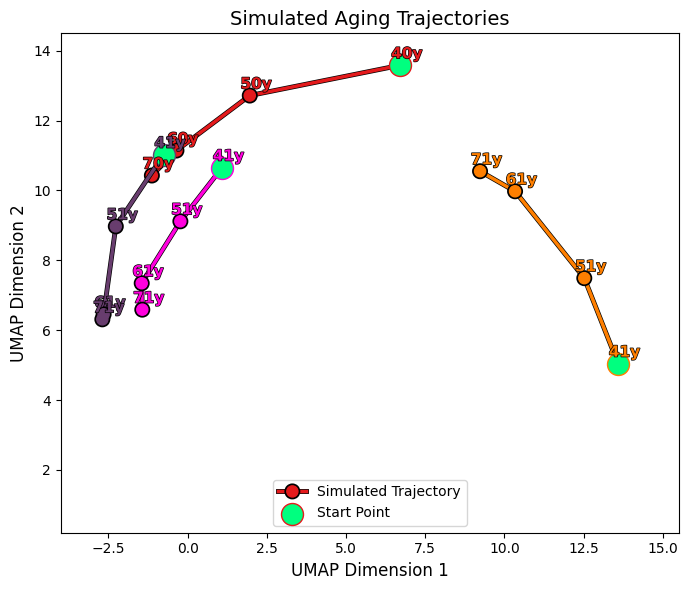

Selecting features using 'ioi' method...
Fitting a single UMAP reducer on all subjects...


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Filtering for subjects with at least 4 visits for stable initialization...
Found 4070 eligible subjects.
Selecting 4 young subjects for simulation...
selected subjects:  ['H4H_16_0526', 'H4H_16_0129', 'H4H_23_0401', 'H4H_16_0348']


c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Kerschbaumer\anaconda3\envs\py\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Analysis complete. Results are ready for plotting.


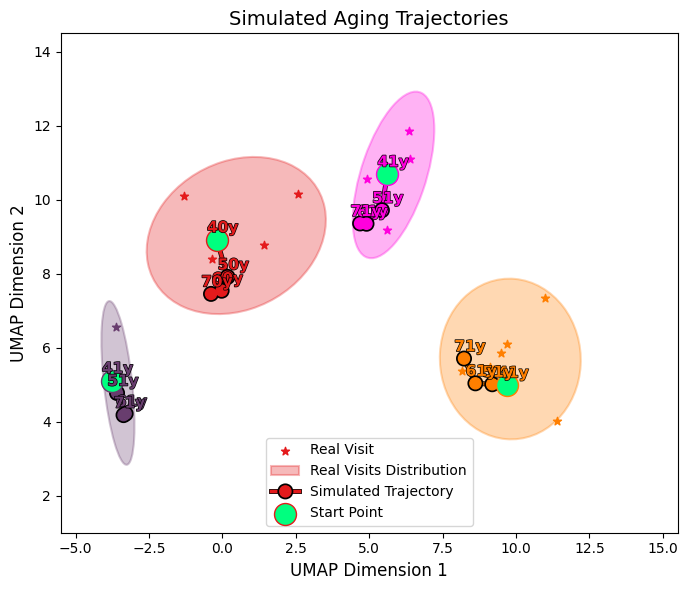

In [239]:
analysis_results = analyze_aging_simulation(
    df=df,
    feature_cols=df.columns[:519],
    model=cvae_model,
    scaler=minmax_scaler,
    n_subjects=4,
    n_samples_per_step=1,
    simulation_steps=3,
    age_step=10,
    feature_selection_method='age_corr',
    n_top_features=30, 
    random_seed=101)

plot_aging_simulation(
    analysis_results, 
    feature_selection_method="age_corr",
    save_path="age_correlated_features_aging_cvae.pdf",
    background = False
)

analysis_results = analyze_aging_simulation(
    df=df,
    feature_cols=df.columns[:519],
    model=cvae_model,
    scaler=minmax_scaler,
    n_subjects=4,
    n_samples_per_step=1,
    simulation_steps=3,
    age_step=10,
    feature_selection_method='ioi',
    n_top_features=30, 
    random_seed=101)

plot_aging_simulation(
    analysis_results, 
    feature_selection_method="ioi",
    save_path="ioi_features_aging_cvae.pdf",
    background = False
)